In [2]:
import numpy as np
import matplotlib.pyplot as plt
import subprocess

The inputs to the script are:
- nu_nu collisions (0); or nu_e collisions (1)
- number of linspace bins
- $\epsilon_{\rm max}$
- filename (from ``QKEMPI`` directory, so ``analysis/`` places the file in this analysis folder)

The code uses ``run_params.hh``
- The initial conditions
- $T_{\rm cm}$
- electron temperature for nu_e collisions

In [4]:
%%time
result = subprocess.run("cd .. && bash script/calc_R.sh 0 201 20 analysis/R_values.csv", shell=True, capture_output=True, text=True)

CPU times: user 5.37 ms, sys: 7.64 ms, total: 13 ms
Wall time: 5min 24s


In [5]:
res = result.stdout
dndt = float(res.split('\n')[0].split('=')[1])
drhodt = float(res.split('\n')[1].split('=')[1])

In [6]:
dndt, drhodt

(3.9977e-10, 7.54499e-10)

In [7]:
data = np.loadtxt("R_values.csv", delimiter=',')

- ``data[0,:]`` are the R values
- ``data[1,:]`` are the $\epsilon$ values
- ``data[2,:]`` are the weights
- ``data[3,:]`` are the ``collision_integral::estimate_load()`` values. They approximate the number of matrix multiplications that need to be performed to calculate the collision integral for the given collision integral

Text(0.5, 0, '$\\epsilon$')

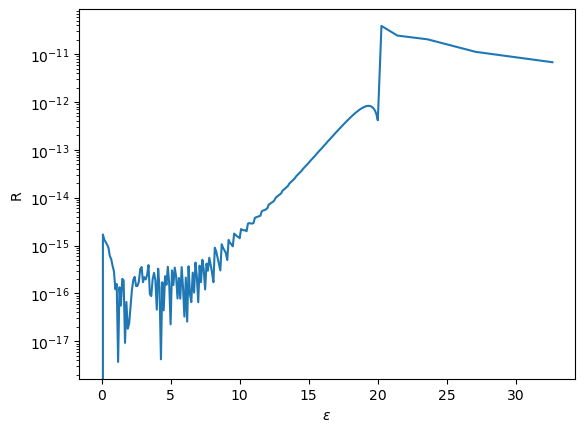

In [9]:
plt.semilogy(data[1,:], data[0,:])
plt.ylabel("R")
plt.xlabel(r"$\epsilon$")